# SBSI tutorial: predicting shear response

This notebook walks through the prediction half of SBSI.

## 1. Setup

Use a kernel in which this SBSI checkout and BlendEMU are installed editable (see the repository README).

## 2. Point SBSI at a catalogue

`load_catalogue` reads a Feather, Parquet, CSV, or pickle path.

The catalogue bundled with this notebook is a truth-level input catalogue. It holds about 111,000 galaxies with sky positions (`RA`, `DEC`), a magnitude (`r`), a size (`Re`), a shape (`sersic_n`, `axis_ratio`, `position_angle`), a `redshift`, and the applied shear (`g1`, `g2`).

If you need fresh simulated or measured catalogues, `job_blendemu.sh` in this folder shows how to call BlendEMU's pipeline. SBSI does not render or measure images itself.

In [1]:
from pathlib import Path

import sbsi
import blendemu

from sbsi import (
    EmulatorPairingConfig,
    ModelPaths,
    ResponsePredictor,
    example_path,
    get_model,
    load_catalogue,
    load_emulator,
    prepare_forward_catalogue,
    predict_blend_response,
)

print("SBSI:    ", sbsi.__file__)
print("BlendEMU:", blendemu.__file__)

SBSI:     /home/z/Zekang.Zhang/SBSI-master/sbsi/__init__.py
BlendEMU: /home/z/Zekang.Zhang/blendemu/blendemu/__init__.py


In [2]:
INPUT_CATALOGUE = example_path("data", "example_catalog.feather")
input_catalogue = load_catalogue(INPUT_CATALOGUE)

input_catalogue.head()

,index,cata_idx,RA,DEC,g1,g2,position_angle,redshift,Re,axis_ratio,sersic_n,r
0,0,773630,180.185728,0.222420,0.0,0.0,164.396647,1.102414,0.162907,0.697792,0.845730,25.733576
1,1,277869,180.118990,0.236218,0.0,0.0,168.168753,0.642087,0.146840,0.341948,0.513552,24.451671
2,2,28030,180.493363,-0.059868,0.0,0.0,91.671930,0.265863,0.396980,0.409923,1.581997,26.839913
3,3,1066306,180.298198,-0.032319,0.0,0.0,152.511604,1.570225,0.155919,0.489980,1.164548,26.660423
4,4,1241052,180.201385,-0.111354,0.0,0.0,41.145542,1.886374,0.192961,0.262081,0.580749,25.564444


## 3. Load the models

In [3]:
# Frozen release paths:
models = get_model("V3")

# An arbitrary model uses the identical workflow:
custom_models = ModelPaths(
    flow_checkpoints=(
        Path("/path/to/models/flow_s1.pt"),
        Path("/path/to/models/flow_s2.pt"),
    ),
    emulator_model=Path("/path/to/models/emulator.json"),
    emulator_metadata=Path("/path/to/models/emulator_metadata.json"),
)

OBSERVING_CONDITIONS = {
    "pixel_size": 0.2,
    "zero_point": 30.0,
    "psf_fwhm": 0.73,
    "moffat_beta": 2.224,
    "pixel_rms": 0.312,
}

models

ModelPaths(flow_checkpoints=(PosixPath('/home/z/Zekang.Zhang/SBSI-master/models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s501_swaavg.pt'), PosixPath('/home/z/Zekang.Zhang/SBSI-master/models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s502_swaavg.pt'), PosixPath('/home/z/Zekang.Zhang/SBSI-master/models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s503_swaavg.pt'), PosixPath('/home/z/Zekang.Zhang/SBSI-master/models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s505_swaavg.pt'), PosixPath('/home/z/Zekang.Zhang/SBSI-master/models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s506_swaavg.pt'), PosixPath('/home/z/Zekang.Zhang/SBSI-master/models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s507_swaavg.pt'), PosixPath('/home/z/Zekang.Zhang/SBSI-master/models/ablation/measurement_flow_g0_ngmix_ablate_s2c_lt500_v22_s508_swaavg.pt'), PosixPath('/home/z/Zekang.Zhang/SBSI-master/models/ablation/measurement_flow_g0_ngmix_ablate_s2c

## 4. Predict the response

The response has two parts, and you always need both:

$$R_{\mathrm{model}} = R_{\mathrm{flow}} + R_{\mathrm{blend}}.$$

`R_flow` is *self*-response: how an isolated galaxy's measured shape reacts to shear. `R_blend` is the extra response caused by neighbours sitting in the way.

By default `predict` refuses to run if any of your galaxies fall outside the domain, and tells you how many. That is deliberate: extrapolating a flow is not a small error. If you would rather drop those rows and carry on, pass `strict_domain=False`.

In [4]:
# Load the two models. device=None picks CUDA when available and CPU otherwise;
# use a GPU node for production-scale flow prediction.
emulator = load_emulator(models, conditions=OBSERVING_CONDITIONS, device="cpu")
predictor = ResponsePredictor.load(models, device=None)
print("Condition features:", predictor.condition_features)
print("Measured targets:  ", predictor.target_features)
print("Training domain:   ", predictor.domain)

Condition features: ('e1_input_p', 'e2_input_p', 'sersic_n_input_p', 'r_input_p', 'Re_input_p', 'nbr_flux_near', 'nbr_flux_far', 'nbr_flux_max')
Measured targets:   ('measured_ngmix_g1', 'measured_ngmix_g2', 'measured_mag_auto', 'measured_log_flux_radius')
Training domain:    Domain(magnitude_min=18.0, magnitude_max=25.8, half_light_radius_min=0.5, half_light_radius_max=1.5)


`prepare_forward_catalogue` runs the neighbour search and hands back both views as ordinary DataFrames you can inspect:

- `flow_inputs` — one row per galaxy that survived the cuts, indexed by its row number in your original catalogue.
- `emulator_pairs` — one row per accepted pair, so a crowded galaxy shows up several times.

(Working across several fields or tiles? Pass `group_column` so a galaxy is never paired with a "neighbour" from a different field.)

In [5]:
pairing = EmulatorPairingConfig.from_emulator(emulator)
prepared = prepare_forward_catalogue(input_catalogue, config=pairing)
prepared.emulator_pairs[["primary_row", "secondary_row", "distance"]].head()

# The pair-level predictions are summed into a Series keyed by primary_row.
r_blend = predict_blend_response(emulator, prepared.emulator_pairs)

prediction = predictor.predict(
    prepared.flow_inputs,
    blend_response=r_blend,
    shear=0.02,
    n_samples=64,
)
prediction.summary()

/home/z/Zekang.Zhang/SBSI-master/sbsi/response.py:196: UserWarning: [blendemu:response] 109874 input rows, extrapolation outside training boundaries:
  sersic_n_input_p: 1762/109874 outside [0.513, 5.85] (input range [0.5, 6])
  sersic_n_input_s: 719/109874 outside [0.513, 5.85] (input range [0.5, 6])
  Predictions for these rows are extrapolations and may be unreliable.
  predicted = emulator.predict_on_pairs(pairs, task="response", rescaled=True)


{'model': 'V3',
 'n_objects': 10265,
 'n_seeds': 16,
 'R_flow': 0.869602157594803,
 'R_blend': 0.24973616911571508,
 'R_total': 1.1193383267105181,
 'R_flow_seed_sem': 0.0036968258907953697}

### Distribution of the two response channels

`prediction.flow` and `prediction.blend` are per-object arrays: each galaxy's
self response, and the extra response its neighbours contribute. Their
distributions show how the two channels split object by object, beyond the
catalogue means in `prediction.summary()`.

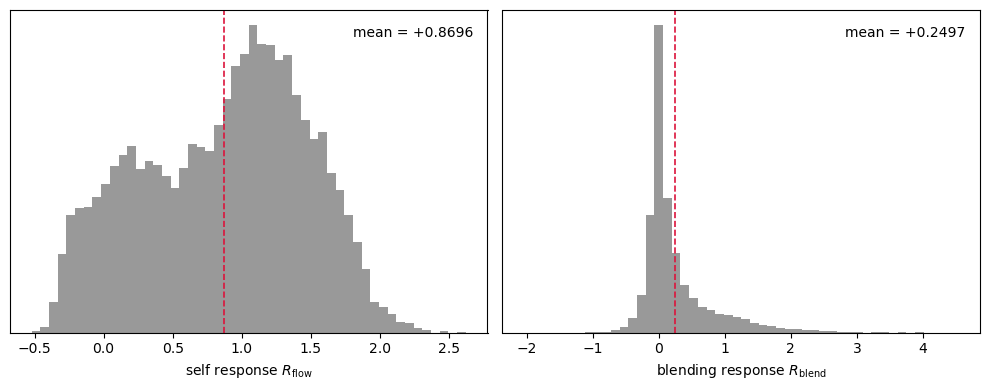

In [6]:
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
channels = (
    (prediction.flow, r"self response $R_{\mathrm{flow}}$"),
    (prediction.blend, r"blending response $R_{\mathrm{blend}}$"),
)
for ax, (values, label) in zip(axes, channels):
    ax.hist(values, bins=50, color="0.6")
    ax.axvline(values.mean(), color="crimson", ls="--", lw=1.2)
    ax.text(0.97, 0.95, f"mean = {values.mean():+.4f}",
            transform=ax.transAxes, ha="right", va="top")
    ax.set_xlabel(label)
    ax.set_yticks([])
fig.tight_layout()
plt.show()

### The flow's direct output: measured-parameter distributions

`predict` reduces the flow to one number per object, but underneath, the flow
models the joint distribution of *four* measured parameters -- shape
($g_1$, $g_2$), magnitude, and size -- conditioned on each galaxy's input
properties. `sample_measurement` draws that distribution directly: pooled
over the 16-seed ensemble at n_samples draws per seed.

In [7]:
from sbsi import sample_measurement

# pick three galaxies: bright, middle, faint
r = prepared.flow_inputs["r_input_p"]

bright = r.idxmin()
middle = (r - r.median()).abs().idxmin()
faint = r.idxmax()

rows = prepared.flow_inputs.loc[[bright, middle, faint]]

draw = sample_measurement(models, rows, n_samples=512)

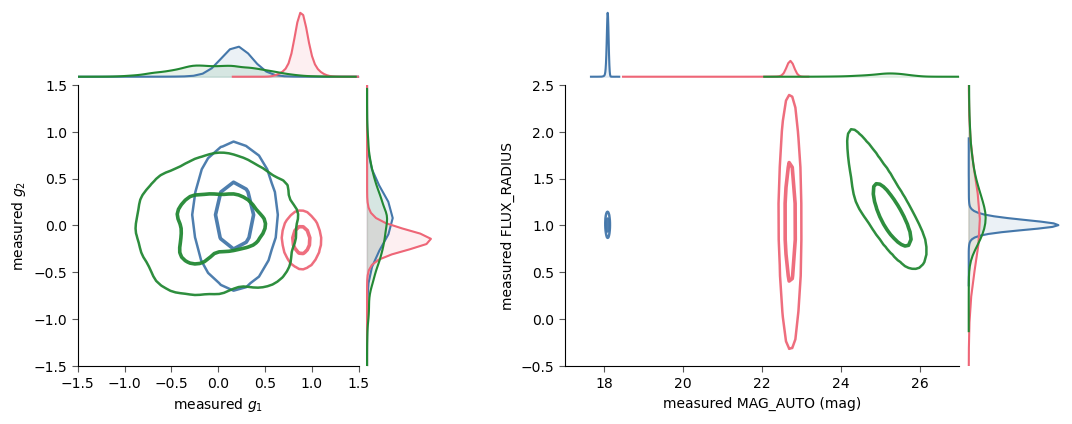

In [9]:
from scipy.ndimage import gaussian_filter, gaussian_filter1d
from mpl_toolkits.axes_grid1 import make_axes_locatable

from sbsi.coordinates import ellipticity_from_axis_ratio_angle


MASS_LEVELS = (0.393, 0.865)  # 1σ, 2σ in 2D
SMOOTHING = 1.6
PAD = int(np.ceil(4 * SMOOTHING))
COLORS = ("#4477AA", "#EE6677", "#228833")


def pad_edges(edges):
    dx = edges[1] - edges[0]
    return edges[0] + dx * np.arange(-PAD, len(edges) + PAD)


def density_contours(ax, x, y, color, bins=50):
    x, y = np.asarray(x), np.asarray(y)
    good = np.isfinite(x) & np.isfinite(y)

    H, xe, ye = np.histogram2d(x[good], y[good], bins=bins)
    H = gaussian_filter(np.pad(H.T, PAD), SMOOTHING)

    xe, ye = pad_edges(xe), pad_edges(ye)
    xc = (xe[:-1] + xe[1:]) / 2
    yc = (ye[:-1] + ye[1:]) / 2

    ranked = np.sort(H.ravel())[::-1]
    cdf = np.cumsum(ranked) / ranked.sum()

    levels = sorted({
        ranked[np.searchsorted(cdf, mass)]
        for mass in MASS_LEVELS
    })

    ax.contour(
        xc,
        yc,
        H,
        levels=levels,
        colors=color,
        linewidths=np.linspace(1.8, 2.6, len(levels)),
        alpha=0.95,
    )


def marginal_density(x, bins=70):
    x = np.asarray(x)
    x = x[np.isfinite(x)]

    H, edges = np.histogram(x, bins=bins)
    H = gaussian_filter1d(
        np.pad(H.astype(float), PAD),
        SMOOTHING,
    )

    edges = pad_edges(edges)
    centers = (edges[:-1] + edges[1:]) / 2
    H /= np.trapz(H, centers)

    return centers, H


def make_joint_axes(fig, spec):
    joint = fig.add_subplot(spec)
    divider = make_axes_locatable(joint)

    top = divider.append_axes(
        "top",
        size="25%",
        pad=0.05,
        sharex=joint,
    )
    right = divider.append_axes(
        "right",
        size="25%",
        pad=0.05,
        sharey=joint,
    )

    top.axis("off")
    right.axis("off")

    return joint, top, right


def add_distribution(axes, x, y, color):
    joint, top, right = axes

    density_contours(joint, x, y, color)

    xx, px = marginal_density(x)
    yy, py = marginal_density(y)

    top.plot(xx, px, color=color, lw=1.5)
    top.fill_between(xx, px, color=color, alpha=0.1)

    right.plot(py, yy, color=color, lw=1.5)
    right.fill_betweenx(yy, py, color=color, alpha=0.1)


fig = plt.figure(figsize=(12, 5.4))
gs = fig.add_gridspec(1, 2, wspace=0.12)

shape_axes = make_joint_axes(fig, gs[0])
phot_axes = make_joint_axes(fig, gs[1])


for (primary_row, galaxy), color in zip(rows.iterrows(), COLORS):
    i = rows.index.get_loc(primary_row)

    g1 = draw.column("measured_ngmix_g1")[i]
    g2 = draw.column("measured_ngmix_g2")[i]
    mag = draw.column("measured_mag_auto")[i]

    radius = (
        np.exp(draw.column("measured_log_flux_radius")[i])
        * OBSERVING_CONDITIONS["pixel_size"]
    )

    add_distribution(
        shape_axes,
        g1,
        g2,
        color,
    )

    add_distribution(
        phot_axes,
        mag,
        radius,
        color,
    )


shape, _, _ = shape_axes
phot, _, _ = phot_axes

shape.set(
    xlabel=r"measured $g_1$",
    ylabel=r"measured $g_2$",
    xlim=(-1.5, 1.5),
    ylim=(-1.5, 1.5),
    aspect="equal",
)

phot.set(
    xlabel="measured MAG_AUTO (mag)",
    ylabel="measured FLUX_RADIUS",
    xlim=(17, 27),
    ylim=(-0.5, 2.5),
)

for ax in (shape, phot):
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(
        direction="out",
        length=4,
        color="0.35",
    )

fig.subplots_adjust(
    left=0.07,
    right=0.95,
    bottom=0.14,
    top=0.80,
)

plt.show()

### Detection probability per galaxy

The same BlendEMU suite ships a detection classifier. `predict_detection`
scores every galaxy in a catalogue from its own properties and its single
nearest neighbour.

In [11]:
detection = emulator.predict_detection(input_catalogue.reset_index(drop=True))
p_detect = detection.loc[prepared.flow_inputs.index, "detection_prob"]
p_detect.describe()

/scratch-local/slurm-job-tmp-15827173/ipykernel_2894634/1136614704.py:1: UserWarning: [blendemu:detection] 111210 input rows, extrapolation outside training boundaries:
  Re_input_p_scaled: 2562/111210 outside [0.187, 0.944] (input range [0.0736, 0.994])
  r_input_p_scaled: 157/111210 outside [20.1, 30.1] (input range [14.8, 20.1])
  sersic_n_input_p: 702/111210 outside [0.513, 5.85] (input range [0.5, 6])
  sersic_n_input_s: 431/111210 outside [0.513, 5.85] (input range [0.5, 6])
  distance_scaled: 4/111210 outside [0.000782, 5.59] (input range [5.6, 5.62])
  Predictions for these rows are extrapolations and may be unreliable.
  detection = emulator.predict_detection(input_catalogue.reset_index(drop=True))


count    10265.000000
mean         0.902745
std          0.243655
min          0.000045
25%          0.962567
50%          0.988946
75%          0.996243
max          0.999381
Name: detection_prob, dtype: float64

mean R_total            = 1.1193
mean R_total x P_detect = 1.0225


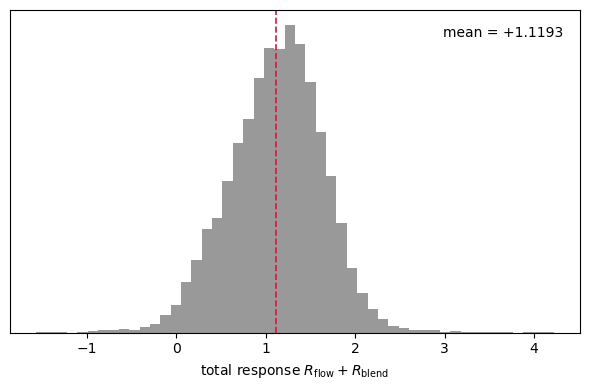

In [12]:
# Total model response per primary, weighted by detection probability.
import pandas as pd

per_primary = pd.DataFrame({
    "R_flow": pd.Series(prediction.flow, index=prediction.index),
    "R_blend": r_blend,
    "P_detect": p_detect,
})
per_primary["R_total"] = per_primary["R_flow"] + per_primary["R_blend"]
per_primary["R_total_detected"] = per_primary["R_total"] * per_primary["P_detect"]
print(
    f"mean R_total            = {per_primary['R_total'].mean():.4f}\n"
    f"mean R_total x P_detect = {per_primary['R_total_detected'].mean():.4f}"
)
# per_primary.head()

# a similar histogram of the total response
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(per_primary["R_total"], bins=50, color="0.6")
mean_total = per_primary["R_total"].mean()
ax.axvline(mean_total, color="crimson", ls="--", lw=1.2)
ax.text(0.97, 0.95, f"mean = {mean_total:+.4f}",
        transform=ax.transAxes, ha="right", va="top")
ax.set_xlabel(r"total response $R_{\mathrm{flow}} + R_{\mathrm{blend}}$")
ax.set_yticks([])
fig.tight_layout()
plt.show()

### Comparing against a simulation

Once you have a matched simulation response, the multiplicative bias is

$$m = R_{\mathrm{sim}} / R_{\mathrm{model}} - 1.$$

```python
m = prediction.multiplicative_bias(simulation_response)
print(f"m = {100 * m:+.3f}%")
```

## 5. Catalogue-level shear inference — not ready yet

The long-term goal is to skip the response-and-bias detour entirely and infer shear directly, putting the measurement flow and the neighbour emulator inside a single simulation-based likelihood.